# 🐍 Python Level 3 - Advanced course
## Class 2 — Object-Oriented Programming
### 📝 Practice Exercises — Solutions

**Python instructor - Catarina Santos**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">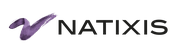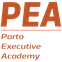</div>

---

---

| Section | Difficulty | Topics |
|---------|------------|--------|
| A | 🟢 Warm-up | a class, `__init__`, attributes, methods |
| B | 🟡 Core practice | methods that decide, and encapsulation |
| C | 🟠 Applied | shared data, internal state, objects in a list |
| D | 🔴 Challenge | inheritance |

> 💡 These are **one** correct answer each. Different attribute names or an extra method is not
> wrong — what matters is that each object holds its own data and the behaviour that goes
> with it.

---

## ⚙️ Setup

In [ ]:
print("Setup complete - let's build some classes!")

---
## 🟢 Section A — Warm-up

> 🕐 Estimated time: 15 min

### Exercise A1 — Your first class

In [ ]:
# A1 - __init__ runs automatically, and self.x stores the value ON the object
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height


small = Rectangle(3, 4)
large = Rectangle(10, 5)

print(small.width, small.height)
print(large.width, large.height)
print(type(small))

### Exercise A2 — A method

In [ ]:
# A2 - a method takes self first, which is how it reaches the object's own data
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        """Return the area of this rectangle."""
        return self.width * self.height


small = Rectangle(3, 4)
large = Rectangle(10, 5)

print(small.area())
print(large.area())

### Exercise A3 — More methods

In [ ]:
# A3 - describe() calls the object's own other methods through self
class Rectangle:
    def __init__(self, width, height):
        self.width = width
        self.height = height

    def area(self):
        """Return the area."""
        return self.width * self.height

    def perimeter(self):
        """Return the distance around the outside."""
        return 2 * (self.width + self.height)

    def is_square(self):
        """True when all four sides are the same."""
        return self.width == self.height

    def describe(self):
        """One line describing this rectangle."""
        return f"{self.width} x {self.height}  area {self.area()}  perimeter {self.perimeter()}"


shape = Rectangle(3, 4)
print(shape.describe())
print(shape.is_square())
print(Rectangle(5, 5).is_square())

### Exercise A4 — Several objects in a list

In [ ]:
# A4 - a list of objects, and one loop that asks each the same question
shapes = [Rectangle(3, 4), Rectangle(10, 5), Rectangle(6, 6), Rectangle(2, 9)]

for shape in shapes:
    print(shape.describe())

areas = [shape.area() for shape in shapes]
print()
print("Total area  :", sum(areas))
print("Largest area:", max(areas))
print("Squares     :", len([s for s in shapes if s.is_square()]))

---
## 🟡 Section B — Core practice

> 🕐 Estimated time: 25 min

### Exercise B1 — A class that changes

In [ ]:
# B1 - a method can change the object's own data
class BankAccount:
    def __init__(self, owner, balance):
        self.owner = owner
        self.balance = balance

    def deposit(self, amount):
        """Add money to the account."""
        self.balance = self.balance + amount


account = BankAccount("Ana Silva", 500.00)
print(account.balance)

account.deposit(250.00)
print(account.balance)

### Exercise B2 — A method that decides

In [ ]:
# B2 - the method checks before it acts, and says what it did
class BankAccount:
    def __init__(self, owner, balance):
        self.owner = owner
        self.balance = balance

    def deposit(self, amount):
        """Add money to the account."""
        self.balance = self.balance + amount

    def withdraw(self, amount):
        """Take money out, but never below zero."""
        if amount > self.balance:
            print(f"Refused: {amount:.2f} is more than the balance of {self.balance:.2f}")
            return False
        self.balance = self.balance - amount
        return True


account = BankAccount("Ana Silva", 500.00)

print(account.withdraw(200.00), account.balance)
print(account.withdraw(1000.00), account.balance)

### Exercise B3 — Keep the balance inside

In [ ]:
# B3 - the underscore says "internal". Everything outside goes through a method,
# so nobody can set a nonsense balance by accident.
class BankAccount:
    def __init__(self, owner, balance):
        self.owner = owner
        self._balance = balance          # internal

    def deposit(self, amount):
        """Add money to the account."""
        self._balance = self._balance + amount

    def withdraw(self, amount):
        """Take money out, but never below zero."""
        if amount > self._balance:
            return False
        self._balance = self._balance - amount
        return True

    def balance(self):
        """A clean way to read the balance from outside."""
        return round(self._balance, 2)


account = BankAccount("Ana Silva", 500.00)
account.deposit(250.00)
account.withdraw(100.00)

print(account.balance())
print(account.owner)

### Exercise B4 — Something every account shares

In [ ]:
# B4 - written in the class body, so there is ONE of it for all accounts
class BankAccount:
    bank_name = "Riverbank"              # shared by every account
    minimum_balance = 0.00

    def __init__(self, owner, balance):
        self.owner = owner
        self._balance = balance

    def withdraw(self, amount):
        """Take money out, but never below the shared minimum."""
        if self._balance - amount < BankAccount.minimum_balance:
            return False
        self._balance = self._balance - amount
        return True

    def balance(self):
        """Read the balance."""
        return round(self._balance, 2)

    def describe(self):
        """One line describing the account."""
        return f"{self.owner:<12}{self.balance():>10.2f}  ({BankAccount.bank_name})"


first = BankAccount("Ana Silva", 500.00)
second = BankAccount("Bruno Costa", 120.00)

print(first.describe())
print(second.describe())
print(first.bank_name, second.bank_name)

---
## 🟠 Section C — Applied

> 🕐 Estimated time: 25 min

### Exercise C1 — Keep a history

In [ ]:
# C1 - the log is internal; history() is the only way in from outside
class BankAccount:
    bank_name = "Riverbank"

    def __init__(self, owner, balance):
        self.owner = owner
        self._balance = balance
        self._history = []               # internal

    def deposit(self, amount):
        """Add money, and note it."""
        self._balance = self._balance + amount
        self._history.append(f"deposit {amount:.2f}")

    def withdraw(self, amount):
        """Take money out if there is enough, and note it."""
        if amount > self._balance:
            self._history.append(f"refused {amount:.2f}")
            return False
        self._balance = self._balance - amount
        self._history.append(f"withdraw {amount:.2f}")
        return True

    def balance(self):
        """Read the balance."""
        return round(self._balance, 2)

    def history(self):
        """Read the log."""
        return list(self._history)


account = BankAccount("Ana Silva", 500.00)
account.deposit(250.00)
account.withdraw(100.00)
account.withdraw(9000.00)

print(account.balance())
for entry in account.history():
    print(" ", entry)

### Exercise C2 — A list of accounts

In [ ]:
# C2 - objects in a list behave like any other list of things
accounts = [
    BankAccount("Ana Silva", 500.00),
    BankAccount("Bruno Costa", 120.00),
    BankAccount("Clara Dias", 2400.00),
    BankAccount("Diogo Melo", 65.50),
]

accounts[0].deposit(250.00)
accounts[2].withdraw(400.00)

print(f"{'owner':<14}{'balance':>10}")
for account in accounts:
    print(f"{account.owner:<14}{account.balance():>10.2f}")

balances = [account.balance() for account in accounts]
print()
print("Accounts   :", len(accounts))
print("Total held :", round(sum(balances), 2))
print("Richest    :", max(balances))
print("Under 100  :", len([b for b in balances if b < 100]))

### Exercise C3 — A method that uses another method

In [ ]:
# C3 - transfer() calls withdraw() on this account and deposit() on the other
class BankAccount:
    bank_name = "Riverbank"

    def __init__(self, owner, balance):
        self.owner = owner
        self._balance = balance

    def deposit(self, amount):
        """Add money."""
        self._balance = self._balance + amount

    def withdraw(self, amount):
        """Take money out if there is enough."""
        if amount > self._balance:
            return False
        self._balance = self._balance - amount
        return True

    def balance(self):
        """Read the balance."""
        return round(self._balance, 2)

    def transfer_to(self, other, amount):
        """Move money to another account, if there is enough."""
        if self.withdraw(amount):
            other.deposit(amount)
            return True
        return False


ana = BankAccount("Ana Silva", 500.00)
bruno = BankAccount("Bruno Costa", 120.00)

print(ana.transfer_to(bruno, 200.00), ana.balance(), bruno.balance())
print(ana.transfer_to(bruno, 5000.00), ana.balance(), bruno.balance())

---
## 🔴 Section D — Challenge

> 🕐 Estimated time: 25 min

### Exercise D1 — A savings account

In [ ]:
# D1 - SavingsAccount starts from BankAccount, adds a rate, and adds one method.
# Everything else - deposit, withdraw, balance - is inherited unchanged.
class SavingsAccount(BankAccount):
    def __init__(self, owner, balance, rate):
        super().__init__(owner, balance)     # let BankAccount do its own set-up
        self.rate = rate

    def add_interest(self):
        """Add one year of interest, and return how much was added."""
        interest = round(self._balance * self.rate / 100, 2)
        self.deposit(interest)               # an inherited method
        return interest


savings = SavingsAccount("Clara Dias", 2000.00, 3.5)

print(savings.owner, savings.balance())
print("Interest added:", savings.add_interest())
print("New balance   :", savings.balance())
print(savings.withdraw(100.00), savings.balance())   # inherited, and it works
print(isinstance(savings, BankAccount))              # True - it IS a BankAccount

### Exercise D2 — Overriding, and one loop over both kinds

In [ ]:
# D2 - each class describes itself its own way, and one loop handles both
class BankAccount:
    bank_name = "Riverbank"

    def __init__(self, owner, balance):
        self.owner = owner
        self._balance = balance

    def deposit(self, amount):
        """Add money."""
        self._balance = self._balance + amount

    def balance(self):
        """Read the balance."""
        return round(self._balance, 2)

    def describe(self):
        """One line describing the account."""
        return f"{self.owner:<14}{self.balance():>10.2f}  current"


class SavingsAccount(BankAccount):
    def __init__(self, owner, balance, rate):
        super().__init__(owner, balance)
        self.rate = rate

    def add_interest(self):
        """Add one year of interest."""
        self.deposit(round(self._balance * self.rate / 100, 2))

    def describe(self):
        """Overrides the parent, to mention the rate."""
        return f"{self.owner:<14}{self.balance():>10.2f}  savings at {self.rate}%"


accounts = [
    BankAccount("Ana Silva", 500.00),
    SavingsAccount("Clara Dias", 2000.00, 3.5),
    BankAccount("Bruno Costa", 120.00),
    SavingsAccount("Diogo Melo", 800.00, 2.0),
]

print("ACCOUNTS")
print("-" * 46)
for account in accounts:
    print(account.describe())         # the right version for each object

# Interest only applies to the savings accounts
for account in accounts:
    if isinstance(account, SavingsAccount):
        account.add_interest()

print("-" * 46)
print("AFTER INTEREST")
for account in accounts:
    print(account.describe())

print("-" * 46)
print("Total held:", round(sum([a.balance() for a in accounts]), 2))

---

### 🎉 Well done!

| | Concept | Exercises |
|-|---------|----------|
| ✅ | `class`, `__init__`, `self` | A1 |
| ✅ | Attributes | A1, B1 |
| ✅ | Methods | A2, A3 |
| ✅ | A method calling another | A3, C3 |
| ✅ | Objects in a list | A4, C2, D2 |
| ✅ | A method that changes the object | B1, B2 |
| ✅ | A method that decides | B2, C3 |
| ✅ | Encapsulation, `_private` | B3, C1 |
| ✅ | Class variables | B4 |
| ✅ | Internal history | C1 |
| ✅ | Inheritance and `super()` | D1, D2 |
| ✅ | Overriding | D2 |
| ✅ | `isinstance` | D1, D2 |

**What D2 was really showing:** one loop, two kinds of object, and each one answered
`describe()` its own way. You did not write an `if` to decide which line to print — the object
already knew. That is what inheritance buys, and it has a name: **polymorphism**.